## **Analysis of Populism Dimensions in the EP**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load classified datasets

elite = pd.read_csv('../data/ep_speeches_anti_elitism.csv')
people = pd.read_csv('../data/ep_speeches_people_centrism.csv')
populism = pd.read_csv('../data/ep_speeches_populism.csv')

In [3]:
# Merge into fully classified ep dataset

shared_cols = elite.columns.intersection(people.columns).tolist()
ep = pd.merge(elite, people, on=shared_cols, how='left')
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0


In [42]:
# Show earliest date and latest date in the dataset
print(f"Earliest date in dataset: {ep['date'].min()}")
print(f"Latest date in dataset: {ep['date'].max()}")

Earliest date in dataset: 1999-07-20 00:00:00
Latest date in dataset: 2024-04-25 00:00:00


In [4]:
# Merge into fully classified ep dataset

shared_cols = ep.columns.intersection(populism.columns).tolist()
ep = pd.merge(ep, populism, on=shared_cols, how='left')
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,prob_non_populism,prob_populism,populism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0,0.995385,0.004615,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0,0.989144,0.010856,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0,0.969885,0.030115,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0,0.993131,0.006869,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0,0.993622,0.006378,0


In [5]:
# Exclude all sentences by actors that are not assigned to a party group (party == "-")
ep = ep[ep["party"] != "-"].copy()
print(f"Remaining rows: {len(ep)}")

Remaining rows: 3872981


In [6]:
# Save full ep dataset 
ep.to_csv('../data/ep_speeches_classified_total.csv', index=False)

In [2]:
# Load full ep dataset
ep = pd.read_csv('../data/ep_speeches_classified_total.csv')
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,prob_non_populism,prob_populism,populism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0,0.995385,0.004615,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0,0.989144,0.010856,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0,0.969885,0.030115,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0,0.993131,0.006869,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0,0.993622,0.006378,0


## **Metrics & Visuals**

#### Adaptations for calculations and plotting

In [3]:
ep['party'].unique()

array(['Greens/EFA', 'PPE', 'S&D', 'Renew', 'ID', 'The Left', 'ECR', 'NI',
       'GUE/NGL', 'ALDE', 'EFDD', 'ENF', 'UEN', 'IND/DEM'], dtype=object)

In [4]:
# Adapt party names to stretch across all periods

ep['party'] = ep['party'].replace({
    'GUE/NGL': 'The Left',
    'ALDE': 'Renew',
    'ENF': 'ID',
    'PPE': 'EPP',
})

In [5]:
# Add a new 'legislative_year' column which indicates years from july to june of the following year
ep['date'] = pd.to_datetime(ep['date'])
ep.insert(9, 'legislative_year', ep['date'].apply(
    lambda x: x.year if x.month < 7 else x.year + 1
))
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,legislative_year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,prob_non_populism,prob_populism,populism_binary
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0,0.995385,0.004615,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0,0.989144,0.010856,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0,0.969885,0.030115,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0,0.993131,0.006869,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0,0.993622,0.006378,0


In [6]:
# Create column of anti-elitism & people-centrism combined 

ep['populism_combined'] = ((ep['anti_elitism_binary'] == 1) & (ep['people_centrism_binary'] == 1)).astype(int)

In [7]:
# Drop columns from populism classifier

ep = ep.drop(columns=["prob_non_populism", "prob_populism", "populism_binary"]).copy()

In [8]:
ep.head()

,unique_id,speech_id,sentence_id,speaker,party,date,agenda,period,year,legislative_year,sentence,prob_non_elitism,prob_anti_elitism,anti_elitism_binary,prob_non_centrism,prob_people_centrism,people_centrism_binary,populism_combined
0,1_1,1,1,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,"Madam President, dear colleagues!",0.945230,0.054770,0,0.735462,0.264538,0,0
1,1_2,1,2,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,Politics must not be for sale.,0.782590,0.217410,0,0.913186,0.086814,0,0
2,1_3,1,3,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,It cannot be that political decisions in this ...,0.235034,0.764966,1,0.880167,0.119833,0,0
3,1_4,1,4,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,"Whether Qatar, Russia, or China – especially w...",0.918710,0.081290,0,0.979357,0.020643,0,0
4,1_5,1,5,Daniel Freund,Greens/EFA,2024-04-25,2. Interinstitutional Body for Ethical Standar...,9,2024,2024,"Even below the threshold of criminal law, belo...",0.885458,0.114542,0,0.982642,0.017358,0,0


In [22]:
# Safe dataset for further analysis
ep.to_csv('../data/ep_speeches_analysis.csv', index=False)

In [9]:
# Define party group order and color palette for plots
group_order = [
    'The Left', 'S&D', 'Greens/EFA', 'Renew', 'EPP', 'IND/DEM', 'UEN', 'ECR', 'EFDD', 'ID', 'NI'
]

In [10]:
group_palette = {
    'The Left':    '#820510',  # dark red - far left
    'S&D':        '#F21818',  # red - social democrats
    'Greens/EFA': '#08730C',  # green
    'Renew':       '#199BF7',  # bright blue - liberals
    'EPP':        '#01548F',  # dark blue - centre-right
    'IND/DEM':    '#88B4CF',  # light blue - eurosceptics
    'UEN':        '#545380',  # purple grey - eurosceptics
    'ECR':        '#116899',  # dark blue - conservatives
    'EFDD':        '#04AEBF',  # teal - eurosceptics 
    'ID':        '#036BAB',  # blue - far right 
    'NI':         '#808080',  # grey - non-attached
}

#### Total Numbers

In [11]:
len(ep)

3872981

In [12]:
len(ep['speech_id'].unique())

505334

In [26]:
# Total anti-elitist sentences
ep['anti_elitism_binary'].value_counts()

anti_elitism_binary
0    3734655
1     138326
Name: count, dtype: int64

In [27]:
# Share of anti-elitist sentences
ep['anti_elitism_binary'].mean()*100

np.float64(3.5715641259278055)

In [28]:
# Total people-centric sentences
ep['people_centrism_binary'].value_counts()

people_centrism_binary
0    3779963
1      93018
Name: count, dtype: int64

In [29]:
# Share of people-centric sentences
ep['people_centrism_binary'].mean()*100

np.float64(2.401715887581168)

In [ ]:
# Total populist sentences
ep['populism_combined'].value_counts()

populism_combined
0    3834843
1      38138
Name: count, dtype: int64

In [58]:
# Share of populist sentences
ep['populism_combined'].mean()*100

np.float64(0.9847195222491408)

### **Populism Distribution across Parties**
##### Sentences (according to each single dimension) by party (normalised)

In [13]:
# References of anti-elitism by party normalised by total sentences per party

party_stats = ep.groupby('party').agg(
    anti_elitism_count=('anti_elitism_binary', 'sum'),
    people_centrism_count=('people_centrism_binary', 'sum'),
    populism_combined_count=('populism_combined', 'sum'),
    total_sentences=('sentence', 'count')
)
party_stats['anti_elitism_normalised'] = party_stats['anti_elitism_count'] / party_stats['total_sentences']*100
party_stats['people_centrism_normalised'] = party_stats['people_centrism_count'] / party_stats['total_sentences']*100
party_stats['populism_combined_normalised'] = party_stats['populism_combined_count'] / party_stats['total_sentences']*100

#### Anti-elitism

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_64593/2686890097.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['anti_elitism_normalised'], palette=group_palette, order=group_order)


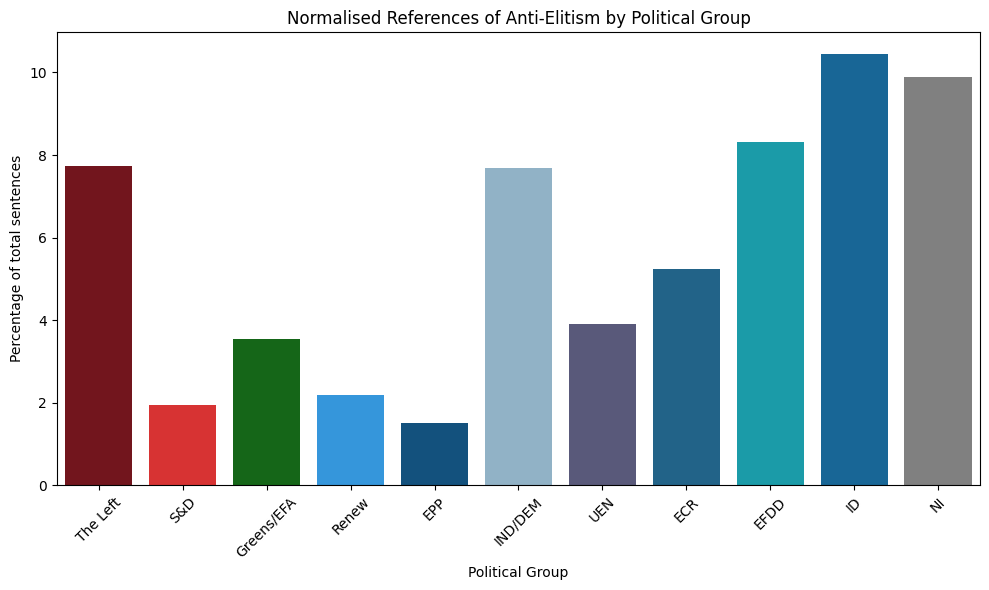

In [39]:
# Visualise references of anti-elitism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['anti_elitism_normalised'], palette=group_palette, order=group_order)
plt.title('Normalised References of Anti-Elitism by Political Group')
plt.xlabel('Political Group')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/normalised_anti_elitism_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

#### People-centrism

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_64593/2535424529.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['people_centrism_normalised'], palette=group_palette, order=group_order)


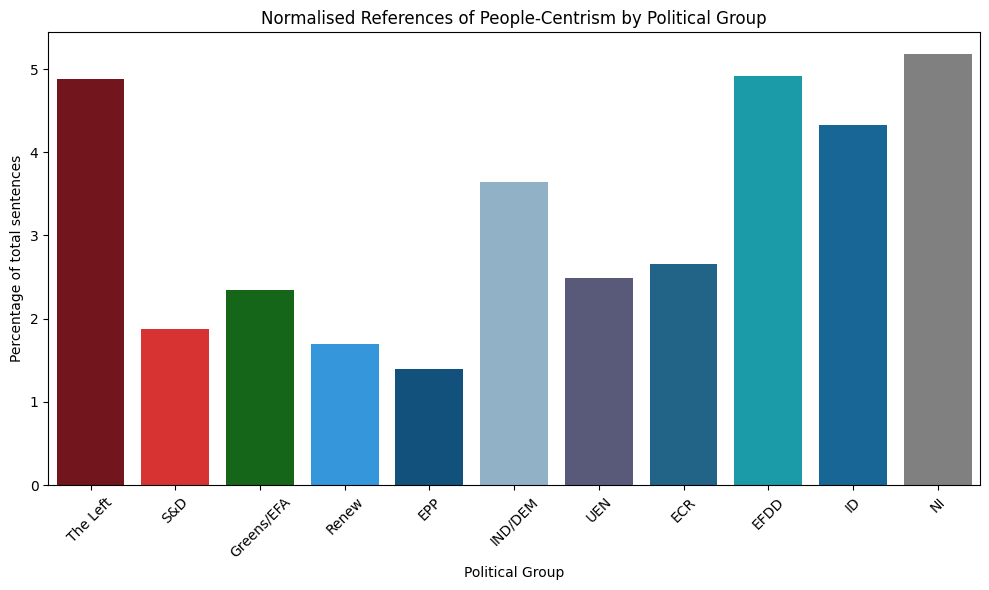

In [40]:
# Visualise references of people-centrism by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['people_centrism_normalised'], palette=group_palette, order=group_order)
plt.title('Normalised References of People-Centrism by Political Group')
plt.xlabel('Political Group')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/normalised_people_centrism_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

#### Populism combined

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_64593/3179171131.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_stats.index, y=party_stats['populism_combined_normalised'], palette=group_palette, order=group_order)


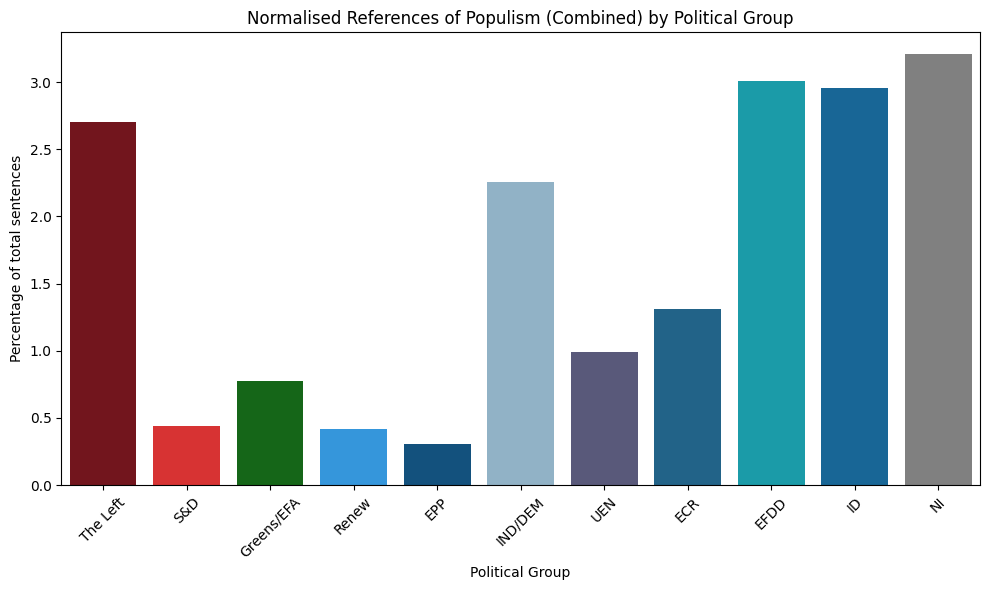

In [41]:
# Visualise references of populism (combined) by party (normalised)

plt.figure(figsize=(10, 6))
sns.barplot(x=party_stats.index, y=party_stats['populism_combined_normalised'], palette=group_palette, order=group_order)
plt.title('Normalised References of Populism (Combined) by Political Group')
plt.xlabel('Political Group')
plt.ylabel('Percentage of total sentences')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/normalised_populism_combined_by_party.png', dpi=150, bbox_inches='tight')
plt.show()

### **Dimensions of Populism over Time**

In [14]:
dimensions = [
    ('anti_elitism_binary', 'Anti-Elitism', '#2166ac'),
    ('people_centrism_binary', 'People-Centrism', '#d6604d'),
    ('populism_combined', 'Populism (combined)', '#4dac26')
]

### Over Legislative Periods

In [15]:
# Total sentences per period for normalisation
period_totals = ep.groupby('period')['sentence'].count().reset_index()
period_totals.columns = ['period', 'total_sentences']

In [16]:
# Sum per period and normalise
dim_cols = [d[0] for d in dimensions]
over_time = ep.groupby('period')[dim_cols].sum().reset_index()
over_time = over_time.merge(period_totals, on='period')
for dim in dim_cols:
    over_time[dim] = (over_time[dim] / over_time['total_sentences']) * 100

In [17]:
print(over_time[dim_cols].describe())

       anti_elitism_binary  people_centrism_binary  populism_combined
count             5.000000                5.000000           5.000000
mean              3.607428                2.413819           0.972222
std               0.879253                0.483199           0.227116
min               2.834205                1.977717           0.740389
25%               2.976515                2.088458           0.781998
50%               3.414354                2.315290           0.936571
75%               3.780090                2.484386           1.129050
max               5.031974                3.203245           1.273102


/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_64593/3756047656.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=over_time, x='period', y=dim,


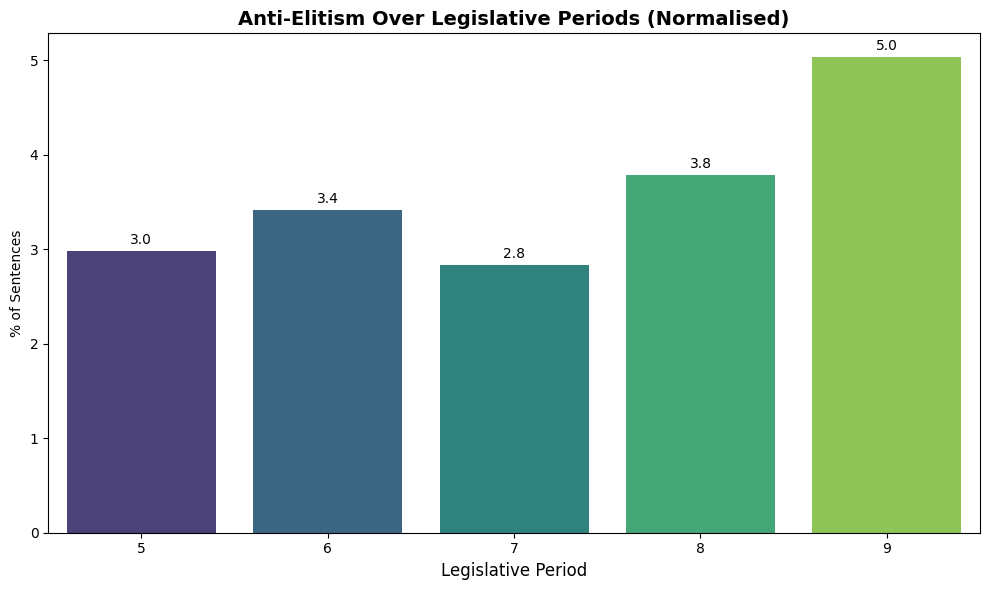

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_64593/3756047656.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=over_time, x='period', y=dim,


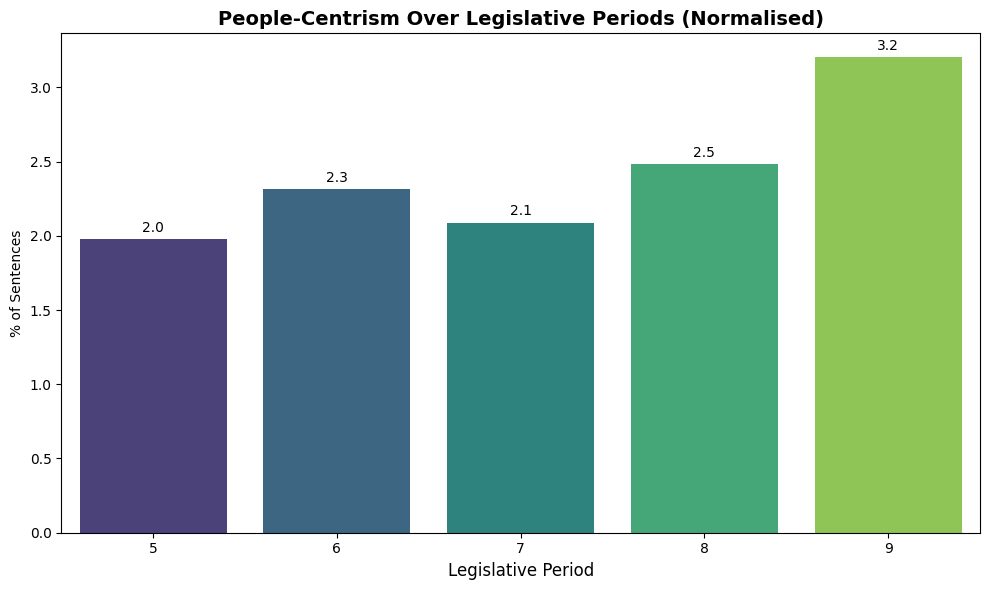

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_64593/3756047656.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=over_time, x='period', y=dim,


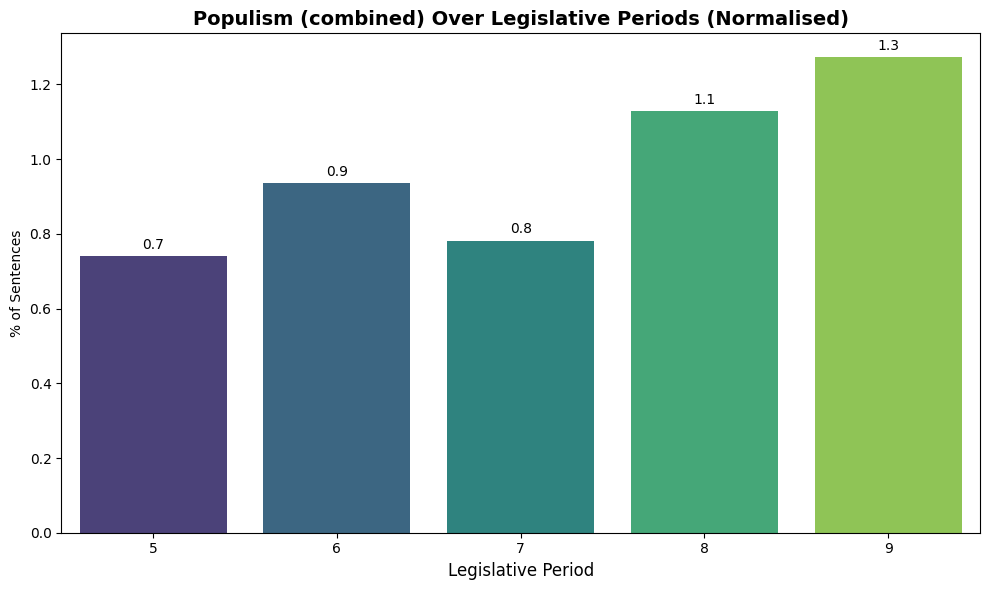

In [18]:
# Single bar charts for each dimension over legislative periods (normalised)
for dim, title, color in dimensions:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=over_time, x='period', y=dim, 
                palette='viridis', ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=10, padding=3)
    ax.set_title(f'{title} Over Legislative Periods (Normalised)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Legislative Period', fontsize=12)
    ax.set_ylabel('% of Sentences')
    plt.tight_layout()
    plt.savefig(f'../outputs/bar_charts/{title.lower().replace(" ", "_")}_over_periods.png', dpi=150, bbox_inches='tight')
    plt.show()

#### Normalised Plots

In [19]:
# Total sentences per year for normalisation
year_totals = ep.groupby('legislative_year')['sentence'].count().reset_index()
year_totals.columns = ['legislative_year', 'total_sentences']

In [20]:
# Sum per year and normalise
dim_cols = [d[0] for d in dimensions]
over_time = ep.groupby('legislative_year')[dim_cols].sum().reset_index()
over_time = over_time.merge(year_totals, on='legislative_year')
for dim in dim_cols:
    over_time[dim] = (over_time[dim] / over_time['total_sentences']) * 100

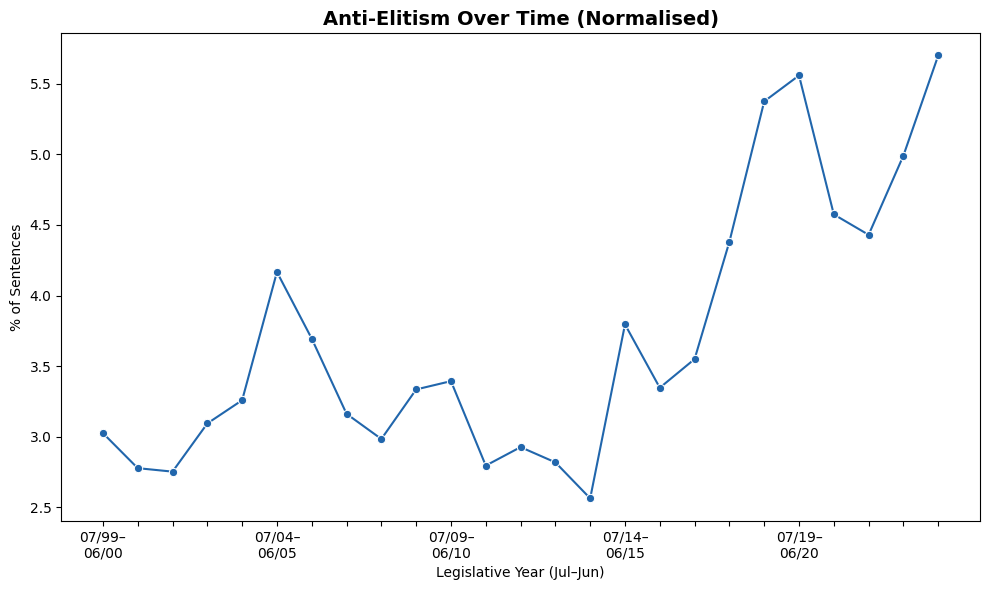

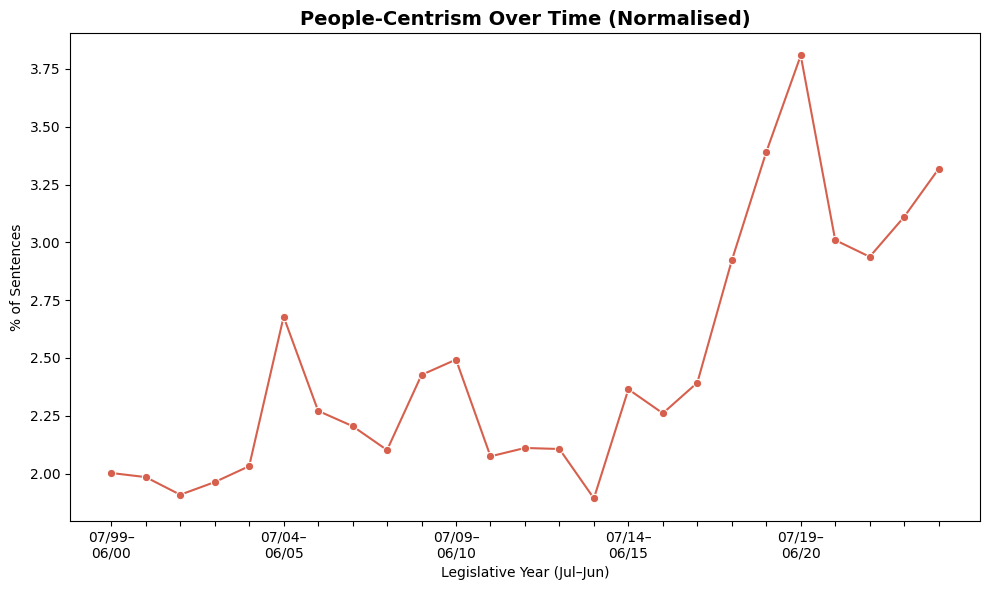

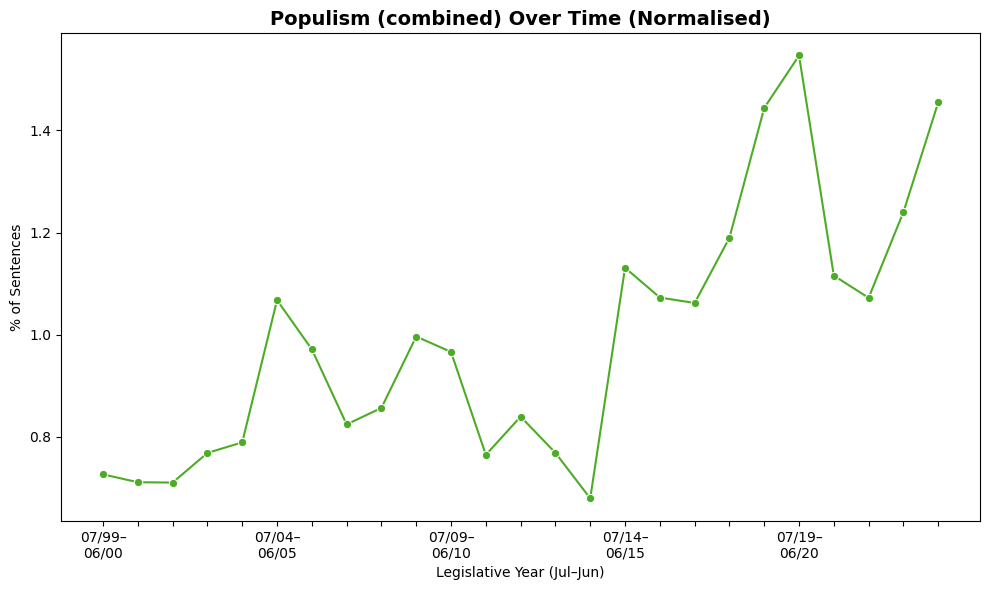

In [26]:
# Plot each dimension separately
for dim, title, color in dimensions:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(data=over_time, x='legislative_year', y=dim, marker='o', color=color, ax=ax)
    ax.set_title(f'{title} Over Time (Normalised)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Legislative Year (Jul–Jun)')
    ax.set_ylabel('% of Sentences')
    
   # Replace x tick labels with Jul/prev_year - Jun/year format
    years = sorted(over_time['legislative_year'].unique())
    ax.set_xticks(years)
    ax.set_xticklabels([f'07/{str(y-1)[2:]}–\n06/{str(y)[2:]}' if y % 5 == 0 else '' 
                        for y in years], rotation=0, ha='center')
    
    plt.tight_layout()
    plt.savefig(f'../outputs/graphs/{title.lower().replace(" ", "_")}_over_time.png', dpi=150, bbox_inches='tight')
    plt.show()

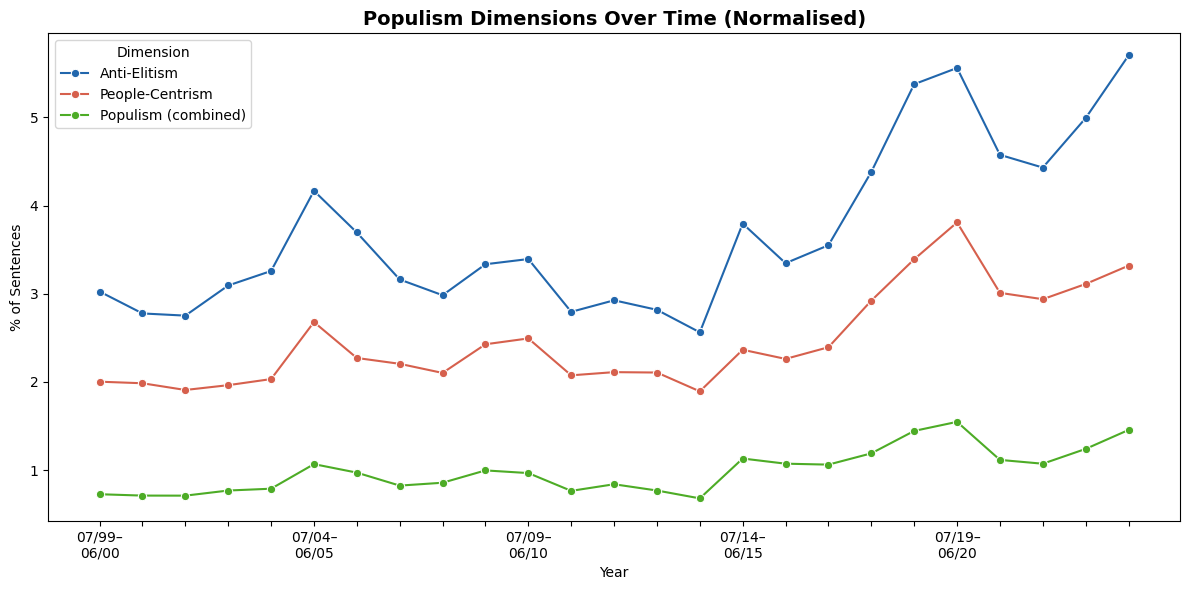

In [28]:
# Combined plot
fig, ax = plt.subplots(figsize=(12, 6))
for dim, title, color in dimensions:
    sns.lineplot(data=over_time, x='legislative_year', y=dim, marker='o', label=title, color=color, ax=ax)
ax.set_title('Populism Dimensions Over Time (Normalised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Sentences')
ax.legend(title='Dimension')

# Replace x tick labels with Jul/prev_year - Jun/year format
years = sorted(over_time['legislative_year'].unique())
ax.set_xticks(years)
ax.set_xticklabels([f'07/{str(y-1)[2:]}–\n06/{str(y)[2:]}' if y % 5 == 0 else '' 
                    for y in years], rotation=0, ha='center')

plt.tight_layout()
plt.savefig('../outputs/graphs/combined_dimensions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


#### All dimensions combined (not normalised)

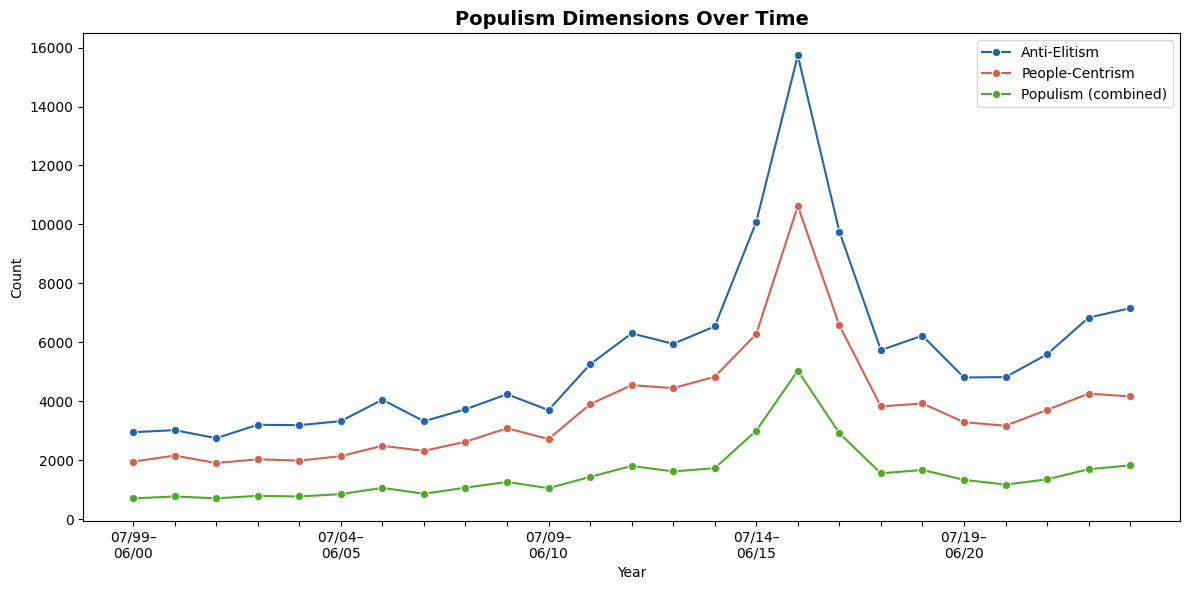

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))

for dim, title, color in dimensions:
    over_time = ep.groupby('legislative_year')[dim].sum().reset_index()
    sns.lineplot(data=over_time, x='legislative_year', y=dim, marker='o', label=title, color=color, ax=ax)

ax.set_title('Populism Dimensions Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.legend()

# Replace x tick labels with Jul/prev_year - Jun/year format
years = sorted(over_time['legislative_year'].unique())
ax.set_xticks(years)
ax.set_xticklabels([f'07/{str(y-1)[2:]}–\n06/{str(y)[2:]}' if y % 5 == 0 else '' 
                    for y in years], rotation=0, ha='center')

plt.tight_layout()
#plt.savefig('../outputs/graphs/combined_dimensions_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

#### Add Election Years

ValueError: Could not interpret value `anti_elitism_binary` for `y`. An entry with this name does not appear in `data`.

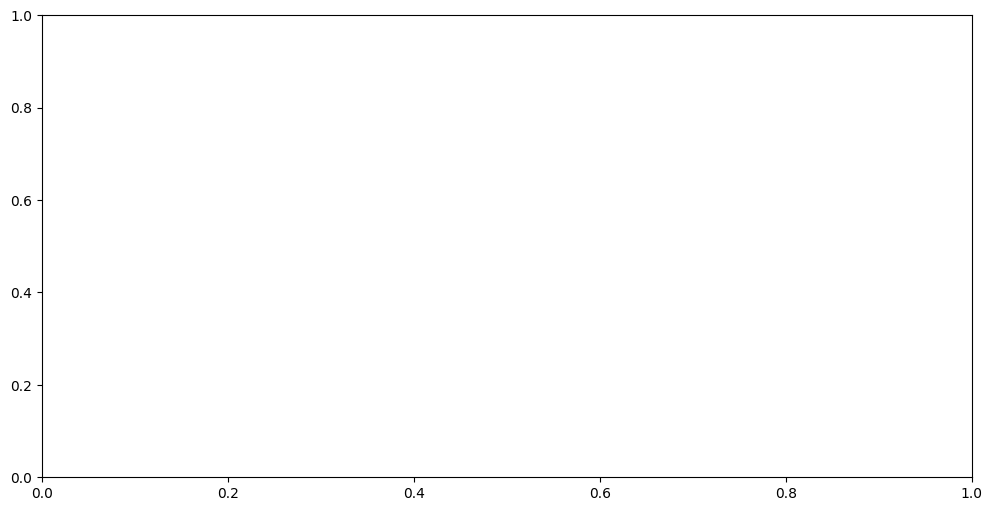

In [30]:
# Combined plot
fig, ax = plt.subplots(figsize=(12, 6))
for dim, title, color in dimensions:
    sns.lineplot(data=over_time, x='legislative_year', y=dim, marker='o', label=title, color=color, ax=ax)

election_years = [2004, 2009, 2014, 2019]
for year in election_years:
    ax.axvline(x=year, color='grey', linestyle='--', alpha=0.7, label='EP Elections ' if year == election_years[0] else '')

ax.set_title('Populism Dimensions Over Time (Normalised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Sentences')
ax.legend(title='Dimension')

# Replace x tick labels with Jul/prev_year - Jun/year format
years = sorted(over_time['legislative_year'].unique())
ax.set_xticks(years)
ax.set_xticklabels([f'07/{str(y-1)[2:]}–\n06/{str(y)[2:]}' if y % 5 == 0 else '' 
                    for y in years], rotation=0, ha='center')

plt.tight_layout()
plt.savefig('../outputs/graphs/combined_dimensions_over_time_elections.png', dpi=150, bbox_inches='tight')
plt.show()

#### Add Crisis Years

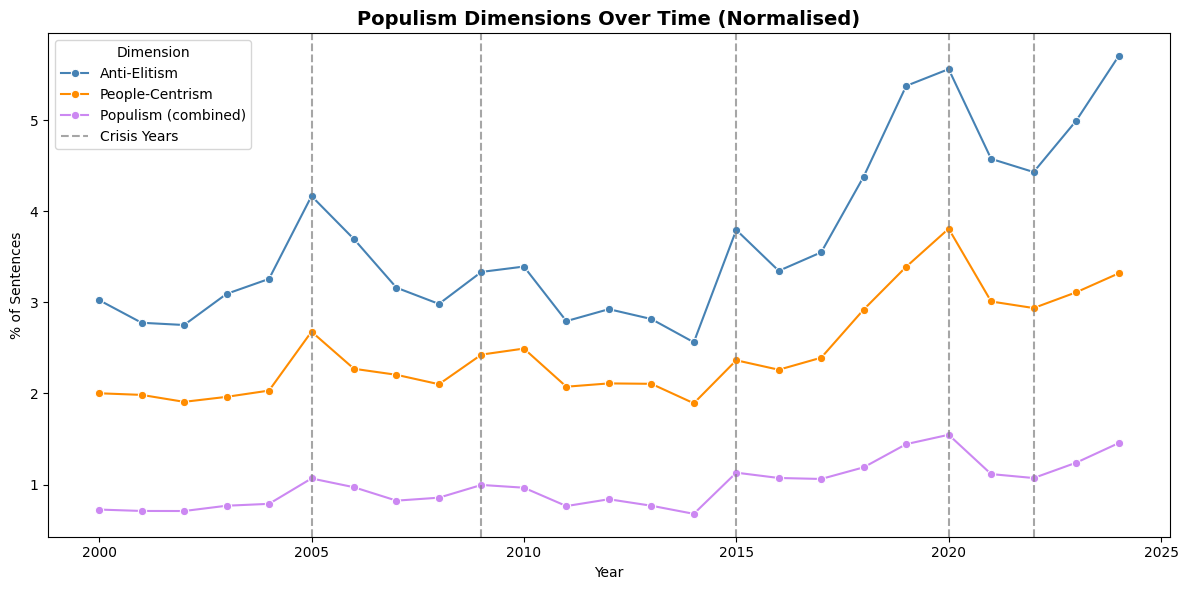

In [51]:
# Combined plot
fig, ax = plt.subplots(figsize=(12, 6))
for dim, title, color in dimensions:
    sns.lineplot(data=over_time, x='legislative_year', y=dim, marker='o', label=title, color=color, ax=ax)

crisis_years = [2005, 2009, 2015, 2020, 2022]
for year in crisis_years:
    ax.axvline(x=year, color='grey', linestyle='--', alpha=0.7, label='Crisis Years ' if year == crisis_years[0] else '')

ax.set_title('Populism Dimensions Over Time (Normalised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Sentences')
ax.legend(title='Dimension')

plt.tight_layout()
plt.savefig('../outputs/graphs/combined_dimensions_over_time_crisis.png', dpi=150, bbox_inches='tight')
plt.show()

## **Indiviudal Metrics**

### Top populist speakers 

In [31]:
speaker_stats = ep.groupby(['speaker', 'party']).agg(
    populism_count=('populism_combined', 'sum'),
    total_sentences=('sentence', 'count')
)
speaker_stats['normalised'] = (speaker_stats['populism_count'] / speaker_stats['total_sentences']) * 100
top20 = speaker_stats[speaker_stats['total_sentences'] >= 50].sort_values('normalised', ascending=False).head(20)
top20.head(20)

,,populism_count,total_sentences,normalised
speaker,party,,,
Γεώργιος Τούσσας,The Left,76,299,25.418060
Charalampos Angourakis,The Left,157,733,21.418827
Georgios Toussas,The Left,309,1499,20.613742
Florian Philippot,EFDD,18,89,20.224719
Claire Fox,NI,43,213,20.187793
Χαράλαμπος Αγγουράκης,The Left,89,442,20.135747
Κωνσταντίνος Παπαδάκης,NI,429,2157,19.888734
Henrik Overgaard Nielsen,NI,10,51,19.607843
Σωτήριος Ζαριανόπουλος,NI,396,2188,18.098720


### Populist Dimensions per Party per Period 

In [33]:
# Total sentences per period-party
total_sentences_pp = ep.groupby(['period', 'party']).size().reset_index(name='total_sentences')

party_period = total_sentences_pp.copy()

# Add normalised share for each dimension
for dim_col, dim_name, *_ in dimensions:
    populist_sentences = ep.groupby(['period', 'party'])[dim_col].sum().reset_index(name=f'{dim_name}_count')
    party_period = pd.merge(party_period, populist_sentences, on=['period', 'party'])
    party_period[f'{dim_name}_share'] = (party_period[f'{dim_name}_count'] / party_period['total_sentences']) * 100

print(party_period)

    period       party  total_sentences  Anti-Elitism_count  \
0        5         EPP           163629                3254   
1        5  Greens/EFA            51556                1492   
2        5     IND/DEM            20433                1130   
3        5          NI            17639                1240   
4        5       Renew            46913                 866   
5        5         S&D           129536                2534   
6        5    The Left            54033                3465   
7        5         UEN            24372                1143   
8        6         EPP           182399                3495   
9        6  Greens/EFA            35596                1274   
10       6     IND/DEM            30603                2796   
11       6          NI            26064                2740   
12       6       Renew            62685                1583   
13       6         S&D           138977                2590   
14       6    The Left            42377                

/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_7019/3685423352.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Period')
/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_7019/3685423352.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Period')
/var/folders/v9/mzn7p8p12456rn1b6p9kv3j80000gn/T/ipykernel_7019/3685423352.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Period')


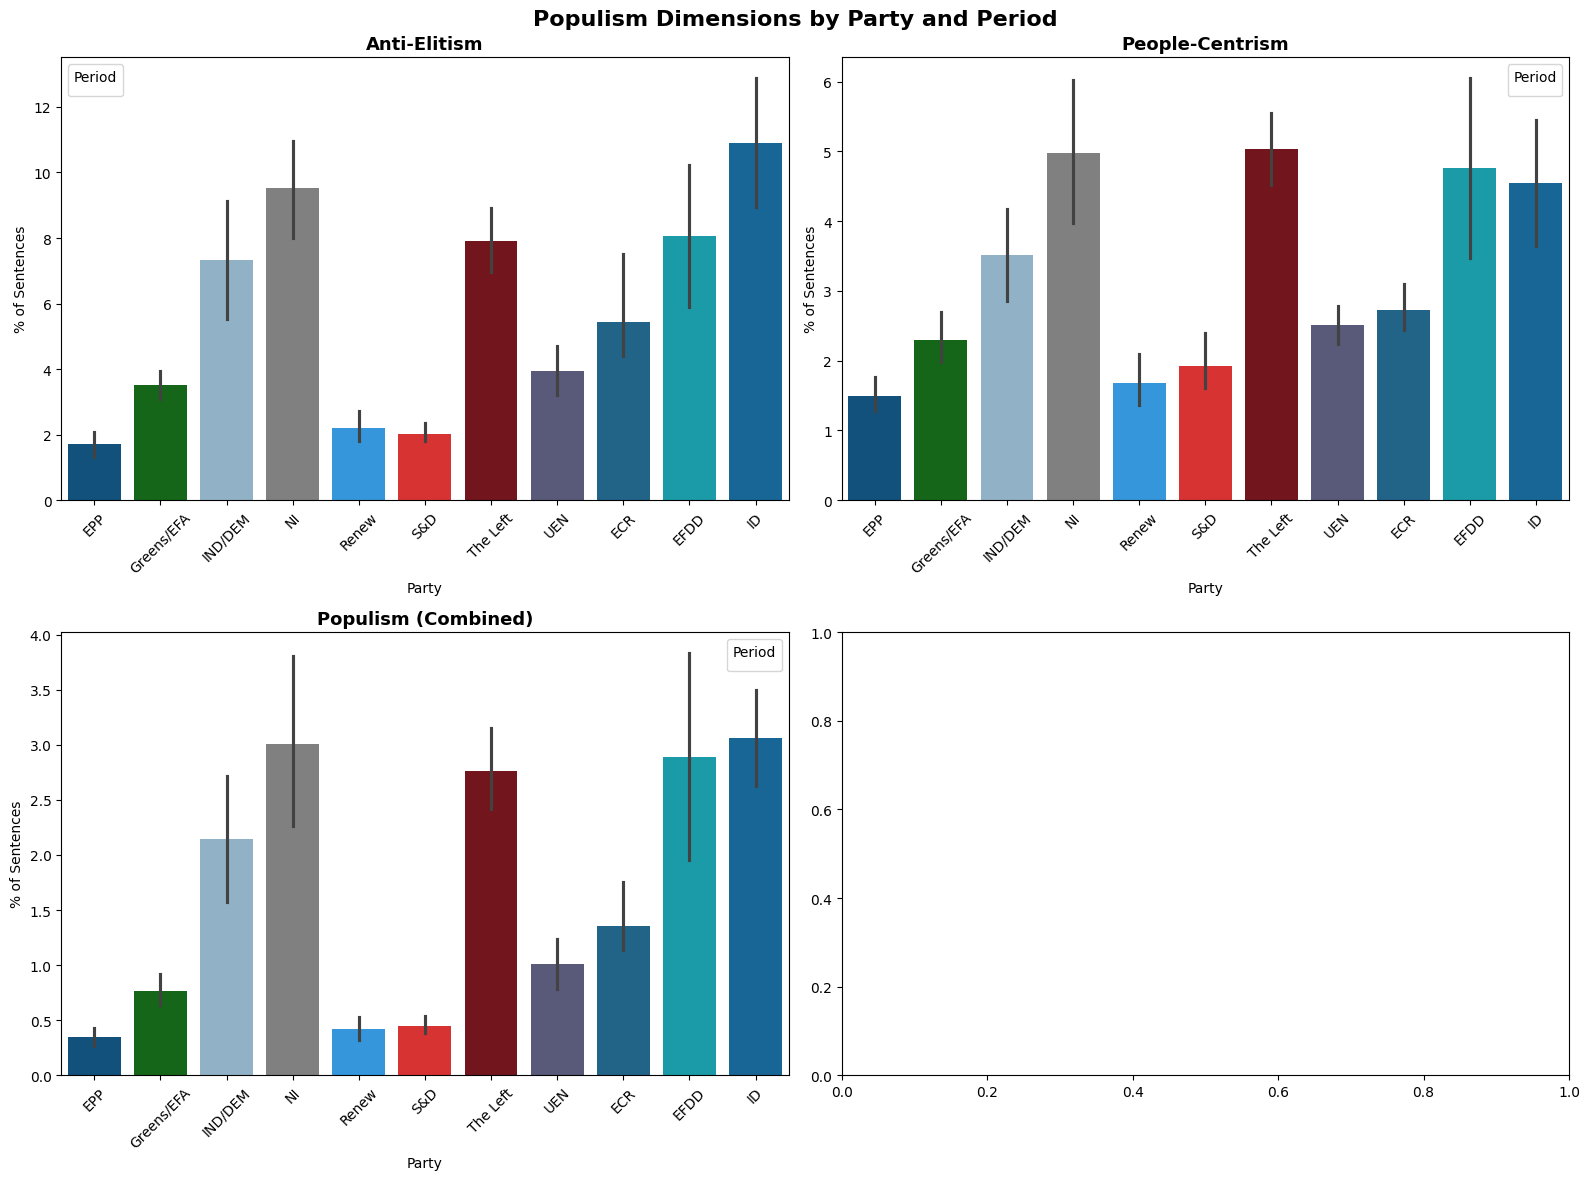

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for (dim_col, dim_name, *_), ax in zip(dimensions[:4], axes.flatten()):
    share_col = f'{dim_name}_share'
    
    sns.barplot(data=party_period, x='party', y=share_col, hue='party', 
                palette=group_palette, hue_order=group_order, ax=ax)
    
    ax.set_title(dim_name.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Party')
    ax.set_ylabel('% of Sentences')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Period')

plt.suptitle('Populism Dimensions by Party and Period', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/graphs/dimensions_party_period.png', dpi=150, bbox_inches='tight')
plt.show()

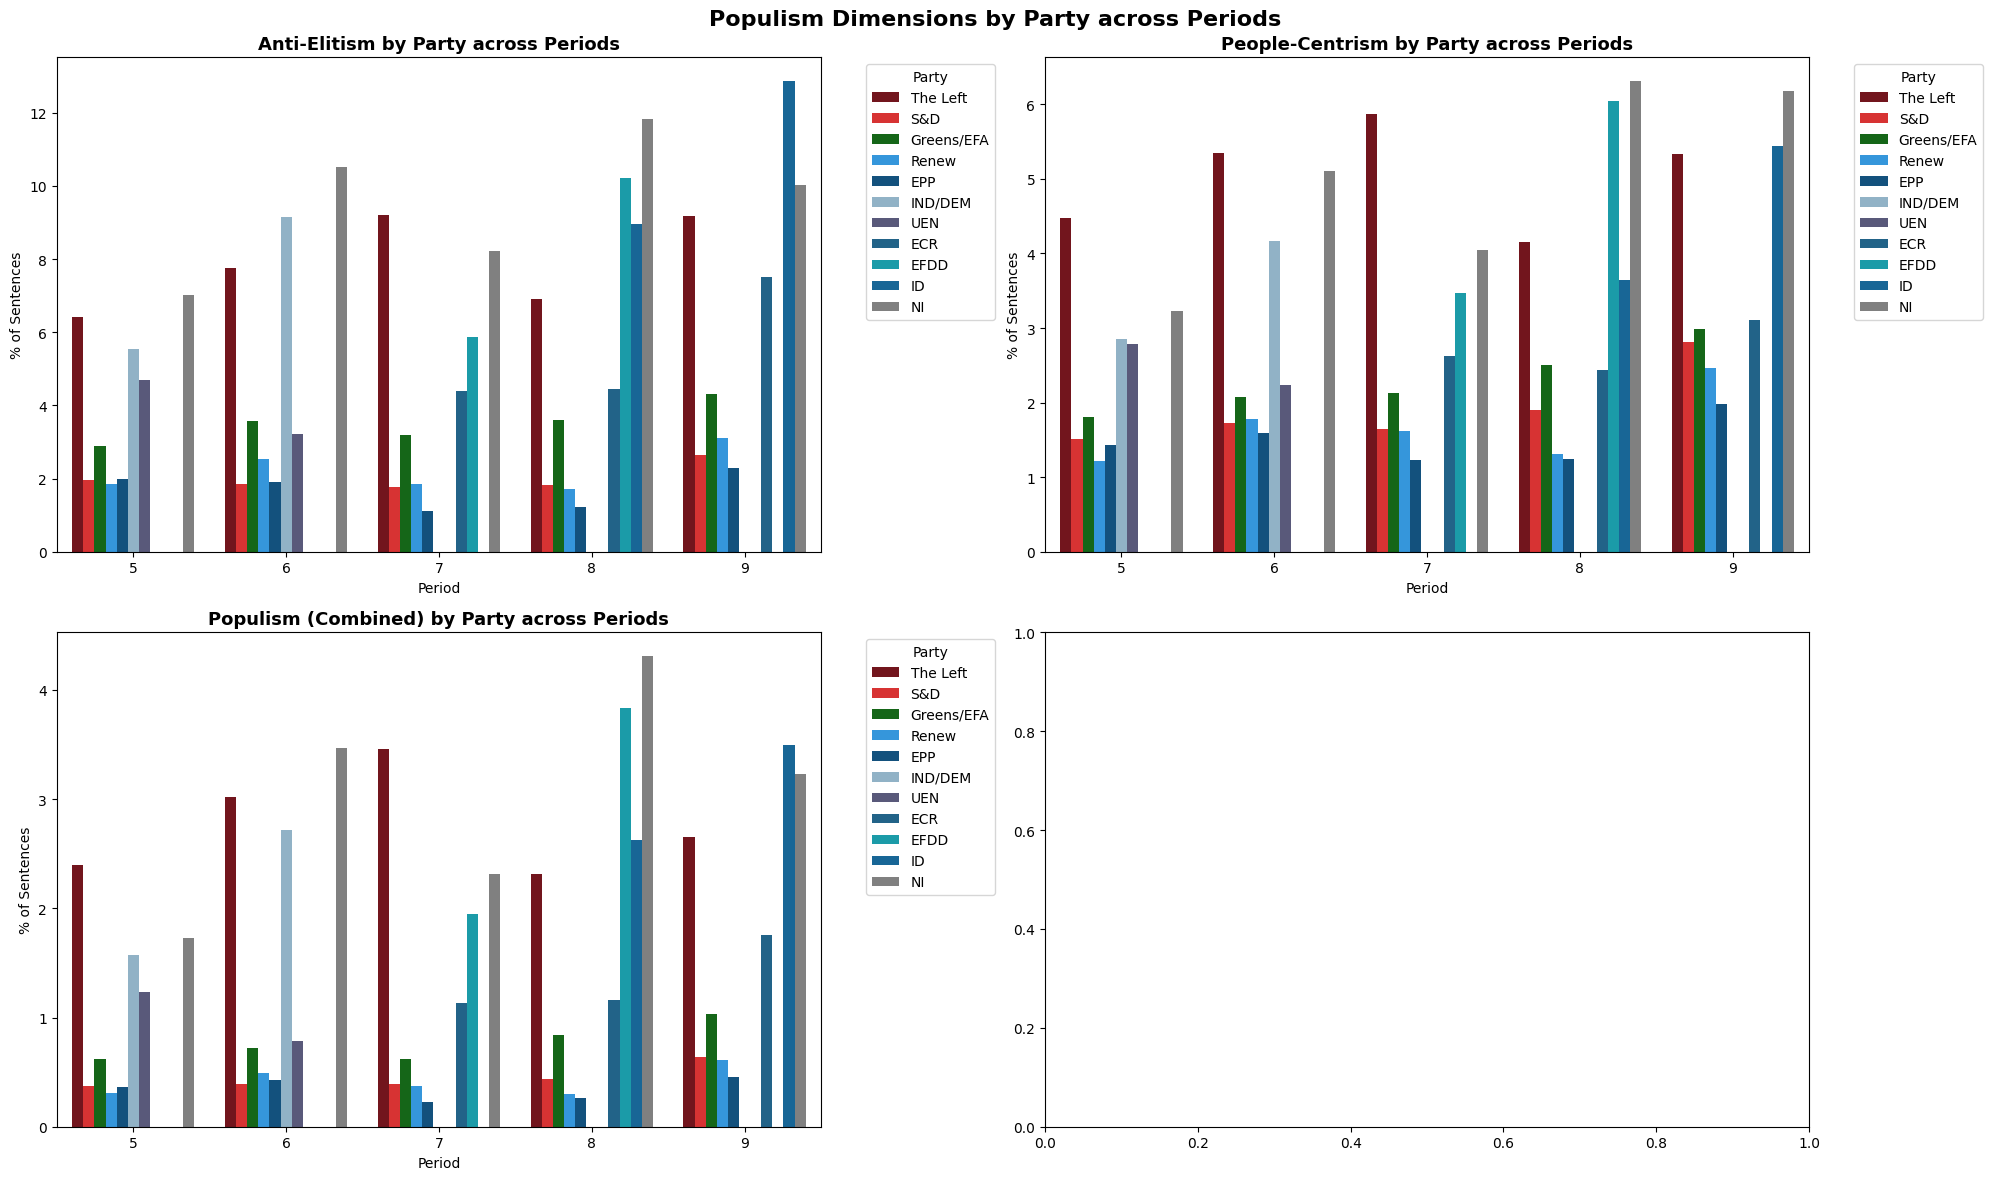

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for (dim_col, dim_name, *_), ax in zip(dimensions[:4], axes.flatten()):
    share_col = f'{dim_name}_share'
    
    sns.barplot(
        data=party_period,
        x='period',
        y=share_col,
        hue='party',
        palette=group_palette,
        hue_order=group_order,
        ax=ax
    )
    ax.set_title(f'{dim_name.replace("_", " ").title()} by Party across Periods', fontsize=13, fontweight='bold')
    ax.set_ylabel('% of Sentences')
    ax.set_xlabel('Period')
    ax.legend(title='Party', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Populism Dimensions by Party across Periods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/bar_charts/dimensions_party_per_period.png', dpi=300, bbox_inches='tight')
plt.show()

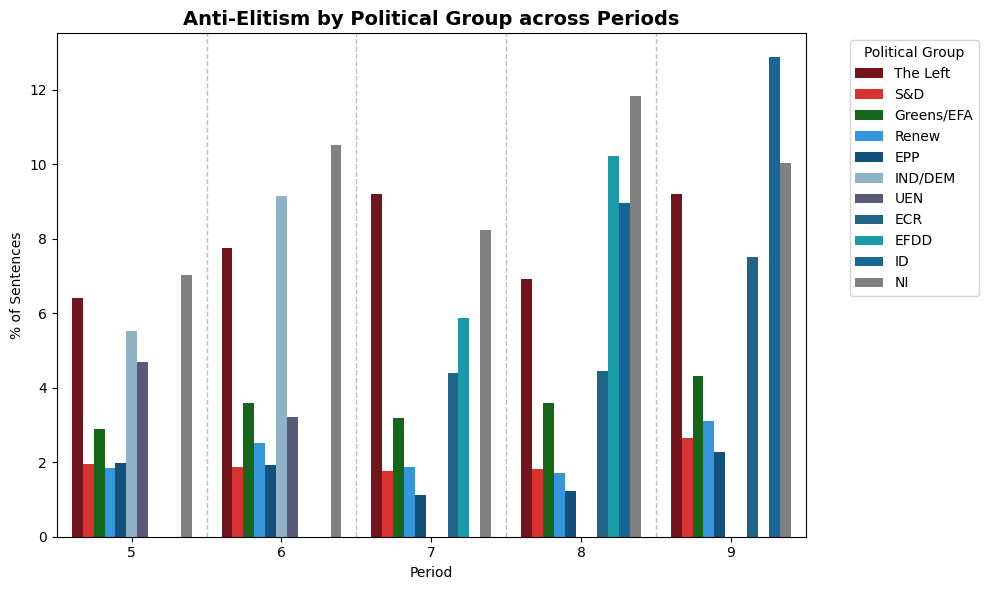

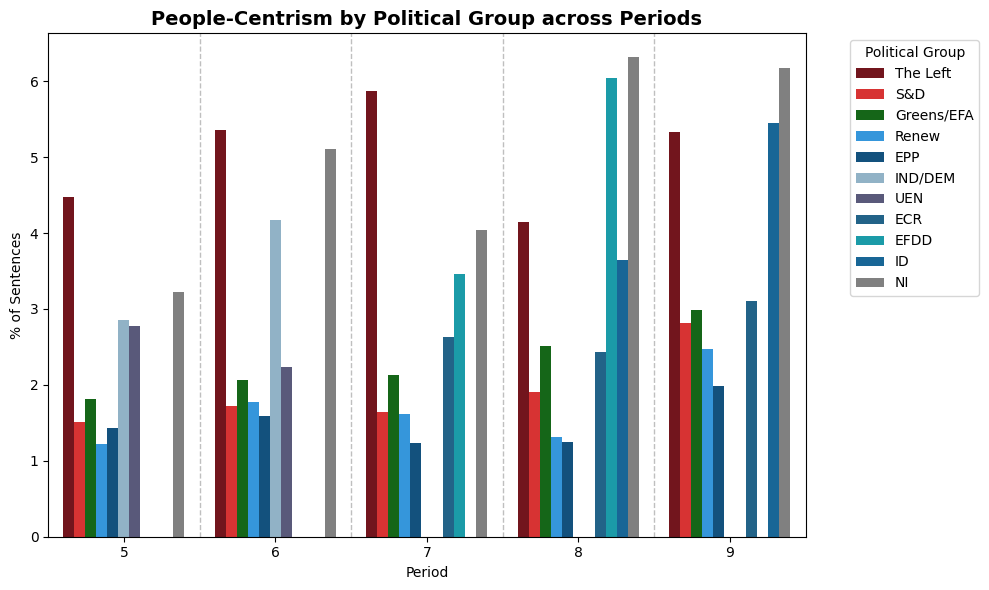

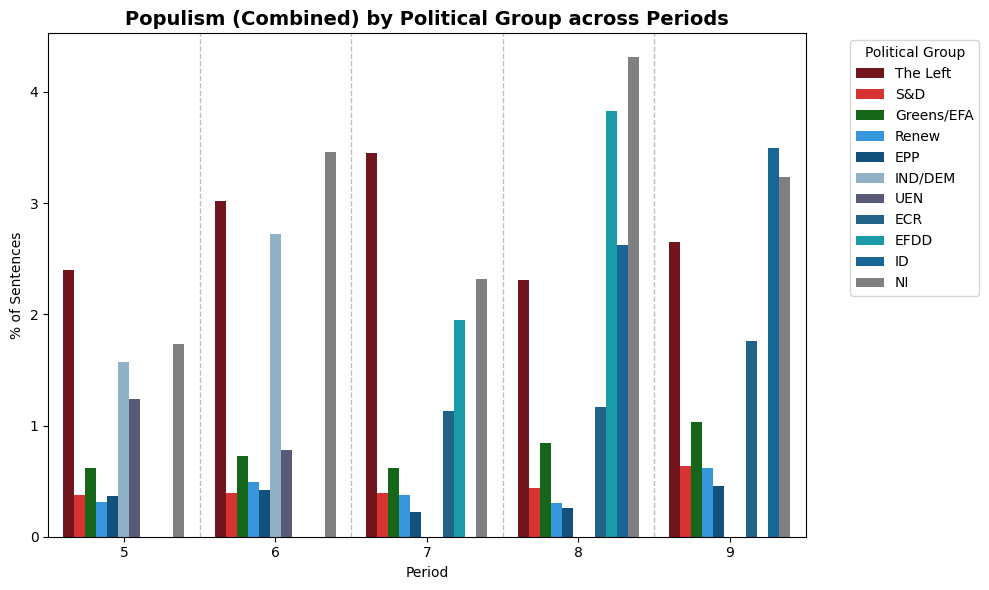

In [43]:
for dim_col, dim_name, *_ in dimensions[:4]:
    share_col = f'{dim_name}_share'
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=party_period,
        x='period',
        y=share_col,
        hue='party',
        hue_order=group_order,
        palette=group_palette,
        ax=ax
    )
    
    # Add vertical separators between periods
    n_periods = len(party_period['period'].unique())
    for i in range(1, n_periods):
        ax.axvline(x=i - 0.5, color='grey', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_title(f'{dim_name.replace("_", " ").title()} by Political Group across Periods', fontsize=14, fontweight='bold')
    ax.set_ylabel('% of Sentences')
    ax.set_xlabel('Period')
    ax.legend(title='Political Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'../outputs/bar_charts/{dim_name}_party_period.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# Relative Populist Discourse by party over time 


plt.figure(figsize=(12, 6))
sns.lineplot(data=populism_over_time, x='year', y='populism_normalised', hue='party', marker='o', palette =line_palette)

plt.title('Relative Populist Discourse by Party Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage of sentences including populist statements')
plt.xticks(sorted(populism_over_time['year'].unique()))
plt.tight_layout()
plt.savefig("Populism_by_party_over_time_normalized.png", dpi=300, bbox_inches="tight")  
plt.show()

In [ ]:
ep.head()